#### Классификация: превышает ли значение СC50 медианное значение выборки

In [15]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.model_selection import GridSearchCV
import seaborn as sns
import matplotlib.pyplot as plt


In [6]:
# Загрузка подготовленных данных
edata = pd.read_csv('edata.csv')
edata

,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,ExactMolWt,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiophene,fr_unbrch_alkane,fr_urea,HydrogenMass
0,6.239374,175.482382,28.125000,5.094096,5.094096,0.387225,0.387225,0.417362,42.928571,384.350449,...,0,0,0,0,0,0,0,3,0,44.352
1,0.771831,5.402819,7.000000,3.961417,3.961417,0.533868,0.533868,0.462473,45.214286,388.381750,...,0,0,0,0,0,0,0,3,0,48.384
2,223.808778,161.142320,0.720000,2.627117,2.627117,0.543231,0.543231,0.260923,42.187500,446.458903,...,0,0,0,0,0,0,0,3,0,58.464
3,107.131532,139.270991,1.300000,5.150510,5.150510,0.270476,0.270476,0.429038,36.514286,466.334799,...,0,0,0,0,0,0,0,0,0,42.336
4,15.037911,30.075821,2.000000,5.758408,5.758408,0.278083,0.278083,0.711012,28.600000,332.225249,...,0,0,0,0,0,0,0,0,0,28.224
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
729,31.000104,34.999650,1.129017,12.934891,12.934891,0.048029,-0.476142,0.382752,49.133333,414.240624,...,0,0,0,0,0,0,0,0,0,34.272
730,31.999934,33.999415,1.062484,13.635345,13.635345,0.030329,-0.699355,0.369425,44.542857,485.277738,...,0,0,0,0,0,0,0,0,0,39.312
731,30.999883,33.999458,1.096761,13.991690,13.991690,0.026535,-0.650790,0.284923,41.973684,545.281109,...,1,0,0,0,0,0,0,0,0,43.344
732,31.998959,32.999644,1.031272,13.830180,13.830180,0.146522,-1.408652,0.381559,39.000000,522.282883,...,0,0,0,0,0,0,0,0,0,42.336


In [7]:
# Медианное значение CC50
ic50_med = edata['CC50, mM'].median()

# Создаём бинарную целевую переменную
edata['CC50h'] = (edata['CC50, mM'] > ic50_med).astype(int)

In [8]:
# Разделение признаков и целевой переменной
X = edata.drop(columns=['IC50, mM', 'CC50, mM', 'SI', 'CC50h'])
y = edata['CC50h'] 

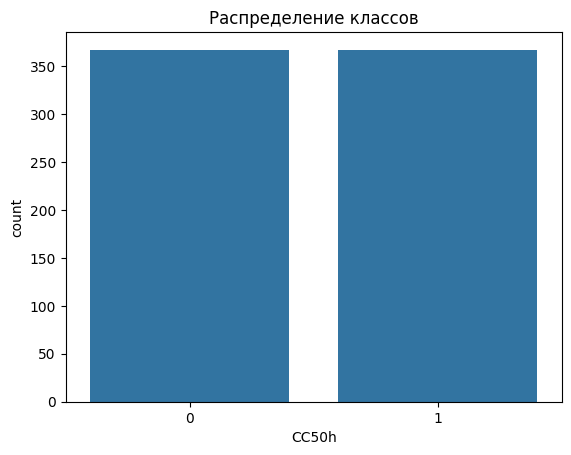

CC50h
0    367
1    367
Name: count, dtype: int64
CC50h
0    0.5
1    0.5
Name: proportion, dtype: float64


In [16]:
# Посмотрим на баланс классов
sns.countplot(x=y)
plt.title("Распределение классов")
plt.show()
# абсолютные значения
print(y.value_counts())
# в процентах
print(y.value_counts(normalize=True)) 

Балансировка не требуется

In [9]:
# Разделим выборку на тестовую и тренировочную
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

In [10]:
# Функция обучения и оценки модели
def eval_fit_model(model, X_train, X_test, y_train, y_test, name="Model" , refit=True):
    if refit:
        model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f"\n{name}")
    cm = confusion_matrix(y_test, y_pred)
    print(cm)
    # Отчёт
    report_dict = classification_report(y_test, y_pred, output_dict=True)
    report_df = pd.DataFrame(report_dict).T.round(3)
    # Выведем как таблицу
    display(report_df.style.set_caption(f"Classification Report: {name}"))
    # ROC-AUC
    y_proba = model.predict_proba(X_test)[:, 1]
    roc_auc = roc_auc_score(y_test, y_proba)
    print(f"ROC-AUC Score: {roc_auc:.4f}")
  

Будем строить модели ипользуя CatBoost, XGBoost и RandomForest.

In [11]:
# Модели
models = {
    'RandomForest': RandomForestClassifier(random_state=42),
    'XGBoost': XGBClassifier(eval_metric='logloss', tree_method='hist', random_state=42),
    'CatBoost': CatBoostClassifier(verbose=0, random_state=42)
}

In [12]:
# Обучение моделей на базовых параметрах, вывод оценок
for name, model in models.items():
    eval_fit_model(model, X_train, X_test, y_train, y_test, name=name)


RandomForest
[[47 27]
 [21 52]]


,precision,recall,f1-score,support
0,0.691000,0.635000,0.662000,74.000000
1,0.658000,0.712000,0.684000,73.000000
accuracy,0.673000,0.673000,0.673000,0.673000
macro avg,0.675000,0.674000,0.673000,147.000000
weighted avg,0.675000,0.673000,0.673000,147.000000


ROC-AUC Score: 0.7548

XGBoost
[[44 30]
 [17 56]]


,precision,recall,f1-score,support
0,0.721000,0.595000,0.652000,74.000000
1,0.651000,0.767000,0.704000,73.000000
accuracy,0.680000,0.680000,0.680000,0.680000
macro avg,0.686000,0.681000,0.678000,147.000000
weighted avg,0.686000,0.680000,0.678000,147.000000


ROC-AUC Score: 0.7433

CatBoost
[[47 27]
 [19 54]]


,precision,recall,f1-score,support
0,0.712000,0.635000,0.671000,74.000000
1,0.667000,0.740000,0.701000,73.000000
accuracy,0.687000,0.687000,0.687000,0.687000
macro avg,0.689000,0.687000,0.686000,147.000000
weighted avg,0.690000,0.687000,0.686000,147.000000


ROC-AUC Score: 0.7522


CatBoost показывает наиболее сбалансированное поведение по precision, recall и f1-score.

Подберем гиперпараметры, обучим модели.

In [13]:
# Параметры для GridSearchCV
rf_params = {
    'n_estimators': [100, 150, 200, 300],
    'max_depth': [5, 10, 15, 20],
    'min_samples_split': [2, 4, 6],
    'min_samples_leaf': [1, 3, 5],
    'max_features': ['sqrt', 'log2']
}

xgb_params = {
    'n_estimators': [100, 200],
    'max_depth': [6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 1.0],
    'colsample_bytree': [0.7, 1.0],
    'reg_alpha': [1, 5], 
    'reg_lambda': [0.1, 1],
    'booster': ['gbtree']
}

cat_params = {
    'depth': [6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'iterations': [100, 300],
    'l2_leaf_reg': [5, 10]
}

# Модели для GridSearchCV
rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid=rf_params,
    cv=3,
    n_jobs=-1,
    scoring='accuracy',
    verbose=1
)

xgbc = GridSearchCV(
    XGBClassifier(eval_metric='logloss', tree_method='hist', random_state=42),
    param_grid=xgb_params,
    cv=3,
    n_jobs=-1,
    scoring='accuracy',
    verbose=1
)

cat = GridSearchCV(
    CatBoostClassifier(verbose=0, random_state=42),
    param_grid=cat_params,
    cv=3,
    n_jobs=-1,
    scoring='accuracy',
    verbose=1
)

In [14]:
# Обучение моделей с подбором гиперпараметров
rf.fit(X_train, y_train)
xgbc.fit(X_train, y_train)
cat.fit(X_train, y_train)

# Вывод лучших найденных параметров
print("Best RF Params:", rf.best_params_)
print("Best XGB Params:", xgbc.best_params_)
print("Best CatBoost Params:", cat.best_params_)

# Оценка качества вывод метрик
eval_fit_model(rf.best_estimator_, X_train, X_test, y_train, y_test, name="RandomForest (Best)", refit=False)
eval_fit_model(xgbc.best_estimator_, X_train, X_test, y_train, y_test, name="XGBoost (Best)", refit=False)
eval_fit_model(cat.best_estimator_, X_train, X_test, y_train, y_test, name="CatBoost (Best)", refit=False)

Fitting 3 folds for each of 288 candidates, totalling 864 fits
Fitting 3 folds for each of 192 candidates, totalling 576 fits
Fitting 3 folds for each of 24 candidates, totalling 72 fits
Best RF Params: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 6, 'n_estimators': 150}
Best XGB Params: {'booster': 'gbtree', 'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 100, 'reg_alpha': 5, 'reg_lambda': 0.1, 'subsample': 0.7}
Best CatBoost Params: {'depth': 6, 'iterations': 300, 'l2_leaf_reg': 5, 'learning_rate': 0.01}

RandomForest (Best)
[[46 28]
 [20 53]]


,precision,recall,f1-score,support
0,0.697000,0.622000,0.657000,74.000000
1,0.654000,0.726000,0.688000,73.000000
accuracy,0.673000,0.673000,0.673000,0.673000
macro avg,0.676000,0.674000,0.673000,147.000000
weighted avg,0.676000,0.673000,0.673000,147.000000


ROC-AUC Score: 0.7511

XGBoost (Best)
[[46 28]
 [19 54]]


,precision,recall,f1-score,support
0,0.708000,0.622000,0.662000,74.000000
1,0.659000,0.740000,0.697000,73.000000
accuracy,0.680000,0.680000,0.680000,0.680000
macro avg,0.683000,0.681000,0.679000,147.000000
weighted avg,0.683000,0.680000,0.679000,147.000000


ROC-AUC Score: 0.7549

CatBoost (Best)
[[44 30]
 [18 55]]


,precision,recall,f1-score,support
0,0.710000,0.595000,0.647000,74.000000
1,0.647000,0.753000,0.696000,73.000000
accuracy,0.673000,0.673000,0.673000,0.673000
macro avg,0.678000,0.674000,0.672000,147.000000
weighted avg,0.679000,0.673000,0.671000,147.000000


ROC-AUC Score: 0.7567


Вывод:
- XGBoost показал наилучшие значения по accuracy и f1-score, что указывает на более сбалансированное качество классификации по-сравнению с другими моделями.
- CatBoost продемонстрировал наивысший ROC-AUC 0.7567, что говорит о лучшем умении модели различать два класса по вероятностным предсказаниям.
- RandomForest после настройки стал ближе к остальным, но не даёт преимущества по ключевым метрикам.


Рекомендации:
 - XGBoost можно выбрать как основную модель для данной задачи, так как она даёт оптимальный баланс между метриками.
 - Если важна максимальная чувствительность к различию классов, можно дополнительно рассмотреть CatBoost, учитывая его высокий ROC-AUC.

